# 05b — Scaling the Surprise Strategy: CPI Only vs CPI + Other Macro Surprises (ES) — NQ

## Purpose

Notebook 04 showed that trading ES in the direction of the **CPI surprise** earns a net Sharpe of about 1.0, but only about **7–11 trades a year**. The peer DTW strategy (Jack Duncan) trades about **185 times a year on ES**.

This notebook asks:

> **If we trade the surprises of many US macro releases, not only CPI, how many trades do we get, and do we keep a positive, credible edge after costs?**

The final section compares **CPI only** against **CPI + other surprises** on trades per year, P&L, return, Sharpe, drawdown, hit rate and costs.

**Scope:** ES only, so the comparison with the peer ES strategy is like for like.

**Credits:** the release-family rule, the impact screen and the volatility-proportional sizing come from **Jack Duncan** (`blackrock-intraday/jack/strategy_proposal.md`). The 5σ winsorisation of surprises comes from **Aaryen Mehta**. The causal surprise standardisation, the executable entry and the walk-forward engine come from this project (Notebooks 01–04).

> **05b — E-mini Nasdaq-100 (NQ).** This notebook is Notebook 05 (ES) run on **NQ**, with identical code and parameters.
> - Prices: Jack Duncan's cleaned 1-minute file `futures_1min_clean_v3_NQ.parquet` (team repo), roll-adjusted the same way. The variables `es` / `es_adj` hold **NQ** bars (names kept from the ES notebook).
> - Costs: 2 ticks + $4.50 per round trip on the NQ contract (tick 0.25, $20 per point).
> - Outputs are saved as `nb05b_NQ_*` (results, figures), so nothing from the ES notebook is overwritten.
> - **Text cells are copied from the ES notebook.** Where they quote ES numbers or say "ES", they describe the ES study; the NQ results are in the outputs.
> - Run order: 03b → 04b → 05b → 06b for the same market (each reads the previous one's files).

## Notebook Workflow

| Step | What happens |
|---|---|
| 1 | Setup and pre-registered parameters |
| 2 | Read every US release in the Bloomberg workbook and group lines into release **families** |
| 3 | Causal, winsorised surprise for every line |
| 4 | ES price measures at every release: jump, tradeable 30-min drift, second 30 min, 4-hour volatility |
| 5 | Validation: the CPI trades must reproduce Notebook 04 |
| 6 | **Impact screen**: each year, admit the 10 families the market reacts to most (history only) |
| 7 | Direction: line signs from the jump regression (history only), then family signals |
| 8 | Strategies: CPI only vs all admitted families; flat, surprise-model and volatility sizing; one vs two windows |
| 9 | Performance, per-family results, robustness (periods, costs, random-sign null) |
| 10 | **Final comparison: CPI only vs CPI + other surprises** |

## Methodology: fixed before looking at results

1. **Entry and exit as in Notebook 04.** Entry at the close of the first post-release bar (about 1 minute after the release, "T+1"), exit 30 minutes after the release. The instant jump is **never** traded.
2. **Release families.** Bloomberg lines that print at the same instant (CPI MoM, Core CPI MoM, CPI YoY and so on) are one release. Lines sharing ≥80% of their timestamps form one family.
3. **Surprise.** $z = (\text{actual} - \text{consensus}) / \text{sd of the line's previous surprises}$, with at least 24 prior releases, capped at ±5σ.
4. **Universe (impact screen).** At the start of each year, using **only earlier data**:
   $$\text{impact}_f = \frac{\text{mean}\,|\text{30-min move}| \text{ on } f\text{'s releases}}{\text{mean}\,|\text{30-min move}| \text{ at the same clock time when another family releases}}$$
   The top **K = 10** families are admitted for that year. No P&L is used.
5. **Direction.** Each line's sign comes from regressing the **instant jump** on its surprise over earlier years, which avoids any drift P&L. The family signal is $x = \text{mean}(\text{sign} \times z)$, so $x>0$ always means *good news for ES*.
6. **Three sizing rules:**
   - **Naive:** one unit in the direction of $x$.
   - **Surprise model:** $\hat r = \hat b_f\,x$, re-fitted on the family's earlier releases; trade only if $|\hat r|$ exceeds the cost.
   - **Signal × volatility (Jack):** position ∝ clip($x$, ±3) × 4-hour volatility / its historical median, normalised to about 1 unit on average.
7. **Costs** are the same as Notebook 04: 2 ticks round trip plus $4.50 commission per contract.
8. **Evaluation** covers 2019–2026, the same window as Notebook 04. 2016–2018 is history only.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys, importlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

MARKET = "NQ"                      # this notebook's market
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
MARKET_FILE = TEAM_DATA / f"futures_1min_clean_v3_{MARKET}.parquet"   # Jack's cleaned 1-minute file
TICK, MULT = {f"{MARKET}": (0.25, 50.0), "NQ": (0.25, 20.0), "ZN": (1 / 64, 1000.0)}[MARKET]   # tick, $ per point
_BARS = {}
def load_market_minute():
    """1-minute bars of MARKET as [close, instrument_id] (loaded once, then cached).
    The variables `es` / `es_adj` below hold THIS market's bars (names kept from the ES notebook)."""
    if "bars" not in _BARS:
        import src.multi_asset as _ma
        _BARS["bars"] = _ma.load_bars(MARKET_FILE, "team_v3")
    return _BARS["bars"]

for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BBG_FILE = RAW_DIR / "Bloomberg Economic Releases.xlsx"
NB04_LOG = RESULTS_DIR / f"nb04b_{MARKET}_trade_log.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
import src.surprise_universe as su
for m in (sc, wf, su):
    importlib.reload(m)

for f in [BBG_FILE, MARKET_FILE, NB04_LOG]:
    print(f"{f.name:<40s} exists: {f.exists()}")

Bloomberg Economic Releases.xlsx         exists: True
futures_1min_clean_v3_NQ.parquet         exists: True
nb04b_NQ_trade_log.csv                   exists: True


In [2]:
# ---- market switch: costs, titles --------------------------------------------
if "wf" in globals():                       # walk-forward costs use this market's contract
    wf.ES_TICK, wf.ES_MULTIPLIER = TICK, MULT
import re as _re, matplotlib.axes as _mx, matplotlib.figure as _mf
if not getattr(_mx.Axes.set_title, "_mkt", False):
    _T0_, _S0_ = _mx.Axes.set_title, _mf.Figure.suptitle
    def _set_title(self, label, *a, **k):
        return _T0_(self, _re.sub(r"\bES\b", MARKET, str(label)), *a, **k)
    def _suptitle(self, t, *a, **k):
        return _S0_(self, _re.sub(r"\bES\b", MARKET, str(t)), *a, **k)
    _set_title._mkt = True
    _mx.Axes.set_title, _mf.Figure.suptitle = _set_title, _suptitle
print(f"MARKET = {MARKET} | file: {MARKET_FILE.name} (exists: {MARKET_FILE.exists()}) | tick {TICK:g}, ${MULT:g} per point"
      f" | cost 2 ticks + $4.50 = {2 * TICK + 4.5 / MULT:.4f} points per round trip")

MARKET = NQ | file: futures_1min_clean_v3_NQ.parquet (exists: True) | tick 0.25, $20 per point | cost 2 ticks + $4.50 = 0.7250 points per round trip


### 1.1 Pre-registered parameters

In [3]:
HIST_START = "2016-01-01"      # history used for screens, signs and model fits
EVAL_START, EVAL_END = "2019-01-01", "2026-06-30"
EVAL_YEARS = list(range(2019, 2027))
K_FAMILIES = 10                # families admitted each year (Jack's specification)
MIN_TRAIN = 24                 # earlier releases needed before a family is modelled
TICKS_RT, COMMISSION_RT = 2.0, 4.5
THRESHOLD = 1.0                # surprise model trades if |E[r]| > 1 x cost
N_NULL, N_BOOT = 1000, 5000
CPI = "CPI"
PRIMARY_TARGET = "w1"          # T+1 -> T+30, the Notebook 04 window
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25
print(f"Evaluation {EVAL_START} to {EVAL_END} ({N_YEARS:.2f} years), K = {K_FAMILIES}")

Evaluation 2019-01-01 to 2026-06-30 (7.49 years), K = 10


## 2. US Releases and Release Families

In [4]:
t0 = time.time()
rows = su.load_bloomberg(BBG_FILE)
print(f"Release rows: {len(rows):,}  |  lines (tickers): {rows['ticker'].nunique()}  |  read in {time.time()-t0:.0f}s")
print("Range:", rows["ts_et"].min(), "to", rows["ts_et"].max())

fam = su.build_families(rows)
print(f"\nLines with >= 30 releases since 2013: {len(fam)}  ->  families: {fam['family'].nunique()}")
fam_summary = (fam.groupby("family")
                  .agg(lines=("ticker", "size"), clock=("clock_et", lambda s: s.mode().iat[0]),
                       releases=("n_releases", "max"),
                       example_lines=("event_name", lambda s: "; ".join(list(s)[:4])))
                  .sort_values("lines", ascending=False))
display(fam_summary.head(25))

Release rows: 27,137  |  lines (tickers): 179  |  read in 1s
Range: 2010-01-04 10:00:00-05:00 to 2026-07-17 10:00:00-04:00

Lines with >= 30 releases since 2013: 143  ->  families: 75


,lines,clock,releases,example_lines
family,,,,
Employment Report (NFP),10,08:30,162,Average Hourly Earnings MoM; Average Hourly Ea...
CPI,8,08:30,162,CPI MoM; Core CPI YoY; CPI YoY; Core CPI Index SA
Personal Income / PCE,7,08:30,160,Real Personal Spending; Core PCE Price Index M...
PPI,6,08:30,149,PPI Final Demand MoM; PPI Ex Food and Energy M...
U. of Michigan Sentiment,5,10:00,325,U. of Mich. Current Conditions; U. of Mich. Ex...
Durable Goods,4,08:30,290,Cap Goods Orders Nondef Ex Air; Cap Goods Ship...
Housing Starts,4,08:30,176,Building Permits MoM; Housing Starts MoM; Buil...
GDP,4,08:30,160,GDP Annualized QoQ; GDP Price Index; Core PCE ...
Retail Sales,4,08:30,163,Retail Sales Advance MoM; Retail Sales Ex Auto...


**Check.** CPI MoM, Core CPI MoM, CPI YoY and the CPI index lines should form one **CPI** family. Payrolls, the unemployment rate and hourly earnings should form one **Employment Report** family. Each is one print, so each is one trade.

## 3. Causal Surprises

In [5]:
surp = su.standardise_surprises(rows)
surp = surp[surp["ticker"].isin(fam["ticker"])]
print(f"Surprise rows with a consensus: {len(surp):,}  |  with a causal z-score: {surp['z'].notna().sum():,}")
print(f"Share capped at +/-5 sigma: {(surp['z'].abs() >= 5).mean():.2%}")
display(surp.merge(fam[["ticker", "family"]], on="ticker")
            .query("family == @CPI")[["ts_et", "event_name", "survey_median", "actual", "raw", "z"]].tail(8))

Surprise rows with a consensus: 20,365  |  with a causal z-score: 17,328
Share capped at +/-5 sigma: 0.47%


,ts_et,event_name,survey_median,actual,raw,z
4700,2026-01-13 08:30:00-05:00,CPI Index NSA,324.168,324.054,-0.115,-0.422
4701,2026-02-13 08:30:00-05:00,CPI Index NSA,325.514,325.252,-0.262,-0.968
4702,2026-03-11 08:30:00-04:00,CPI Index NSA,326.762,326.785,0.024,0.087
4703,2026-04-10 08:30:00-04:00,CPI Index NSA,330.555,330.213,-0.342,-1.267
4704,2026-05-12 08:30:00-04:00,CPI Index NSA,332.690,333.020,0.330,1.220
4705,2026-06-10 08:30:00-04:00,CPI Index NSA,335.143,335.123,-0.020,-0.074
4706,2026-07-14 08:30:00-04:00,CPI Index NSA,334.698,333.952,-0.746,-2.762
17061,2019-01-11 08:30:00-05:00,Real Avg Weekly Earnings YoY,1.200,1.184,-0.016,NaN


## 4. ES Price Measures at Every Release

In [6]:
es = load_market_minute()
es_adj, _ = sc.build_adjusted_log_price(es)
ts_all = rows.loc[rows["ts_utc"] >= pd.Timestamp(HIST_START, tz="UTC"), "ts_utc"].unique()
px = su.price_measures(es_adj, ts_all)
px["cost_bps"] = su.cost_bps(px["pre_close"], TICKS_RT, COMMISSION_RT, TICK, MULT)
print(f"Release timestamps since {HIST_START}: {len(px):,}  |  with a 30-min trade return: {px['w1'].notna().sum():,}")
display(px.describe().T[["count", "mean", "std", "min", "50%", "max"]])

Release timestamps since 2016-01-01: 6,097  |  with a 30-min trade return: 5,852


,count,mean,std,min,50%,max
jump,"5,855.000",0.262,15.306,-353.061,0.174,258.376
w1,"5,852.000",-0.167,28.600,-203.276,0.383,424.301
w2,"5,848.000",-0.256,26.726,-243.210,0.332,235.493
react30,"5,852.000",0.091,33.131,-363.200,0.624,443.748
vol_4h,"5,855.000",2.957,1.968,0.512,2.445,30.018
pre_close,"5,855.000","12,552.045","6,529.422","3,898.000","11,893.250","30,791.250"
cost_bps,"5,855.000",0.766,0.409,0.235,0.610,1.860


## 5. Validation: Do the CPI Trades Reproduce Notebook 04?

In [7]:
nb04 = pd.read_csv(NB04_LOG)
nb04["timestamp_utc"] = pd.to_datetime(nb04["timestamp_utc"], utc=True)
nb04_cpi = nb04[(nb04["strategy"] == "Naive sign") & (nb04["event_type"] == "CPI") & nb04["eligible"]]
chk = nb04_cpi.merge(px, left_on="timestamp_utc", right_on="ts_utc", how="inner")
gap = (chk["ret_bps"] - chk["w1"]).abs()
print(f"NB04 CPI trades: {len(nb04_cpi)}  |  matched release timestamps: {len(chk)}")
print(f"Max |NB04 trade return - NB05 w1| = {gap.max():.2e} bps")
if len(chk) < len(nb04_cpi):
    print(f"WARNING: {len(nb04_cpi) - len(chk)} NB04 CPI timestamps are not in the Bloomberg calendar")
assert gap.max() < 1e-6, f"Trade returns differ from Notebook 04: check the {MARKET} file and bar convention"
print("PASSED: the 30-minute trade return is identical to Notebook 04 on every matched CPI release")

NB04 CPI trades: 79  |  matched release timestamps: 79
Max |NB04 trade return - NB05 w1| = 1.42e-14 bps
PASSED: the 30-minute trade return is identical to Notebook 04 on every matched CPI release


## 6. Impact Screen: Which Families Does the Market React To?

Computed once per year from history only. The admitted list can change from year to year.

In [8]:
screens = {}
for y in EVAL_YEARS:
    screens[y] = su.impact_screen(rows, fam, px, HIST_START, f"{y}-01-01")
admit = pd.DataFrame({y: screens[y].set_index("family")["rank"] for y in EVAL_YEARS})
admitted_any = admit[(admit <= K_FAMILIES).any(axis=1)]
print(f"Families ranked each year: {[len(screens[y]) for y in EVAL_YEARS]}")
print(f"\nRank of every family that is admitted (top {K_FAMILIES}) in at least one year:")
display(admitted_any.sort_values(EVAL_YEARS[-1]).astype("Int64"))
print(f"\nScreen used for {EVAL_YEARS[0]} (history {HIST_START} to {EVAL_YEARS[0]-1}):")
display(screens[EVAL_YEARS[0]].head(15))
admit.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_impact_rank_by_year.csv")

Families ranked each year: [31, 38, 39, 39, 40, 41, 42, 45]

Rank of every family that is admitted (top 10) in at least one year:


,2019,2020,2021,2022,2023,2024,2025,2026
family,,,,,,,,
CPI,<NA>,3,2,1,1,1,1,1
Employment Report (NFP),1,1,1,2,4,3,3,2
Fed Interest on Reserve Balances Rate,<NA>,<NA>,<NA>,<NA>,2,2,2,3
FOMC Rate Decision,<NA>,<NA>,3,3,3,4,4,4
Dallas Fed Manf. Activity,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5
ISM Services,5,8,7,9,5,5,5,6
ISM Manufacturing,4,5,11,14,8,9,6,7
U. of Michigan Sentiment,24,29,20,15,7,6,7,8
PPI,14,19,9,8,13,12,10,9



Screen used for 2019 (history 2016-01-01 to 2018):


,family,clock,n,n_control,impact,t,survey_share,rank
0,Employment Report (NFP),08:30,36,376,1.964,3.297,1.000,1
1,Trade Balance,08:30,36,376,1.389,1.267,1.000,2
2,Pending Home Sales MoM,10:00,36,402,1.222,0.960,1.000,3
3,ISM Manufacturing,10:00,36,402,1.209,1.196,1.000,4
4,ISM Services,10:00,36,402,1.203,0.820,1.000,5
5,Factory Orders,10:00,35,403,1.176,0.751,1.000,6
6,NAHB Housing Market Index,10:00,31,407,1.153,0.812,1.000,7
7,GDP,08:30,34,378,1.136,0.572,1.000,8
8,Conf. Board Consumer Confidence,10:00,36,402,1.074,0.389,1.000,9
9,Richmond Fed Manufact. Index,10:00,36,402,1.023,0.136,1.000,10


**How to read it.** An impact of 1.3 means the ES reaction to this family is 30% larger than at the same clock time when a different release is out. Only the top 10 each year are traded. CPI should rank near the top in every year.

## 7. Direction: Line Signs and Family Signals

In [9]:
signs, hist = {}, {}
admitted = {y: set(screens[y].head(K_FAMILIES)["family"]) for y in EVAL_YEARS}
for y in EVAL_YEARS:
    signs[y] = su.line_signs(surp, px, HIST_START, f"{y}-01-01")
    fams_y = admitted[y] | {CPI}
    # training panel for the surprise model: releases before the end of year y
    hist[y] = su.history_panel(surp, fam, px, fams_y, signs[y], HIST_START, f"{y+1}-01-01")

screen_plus_cpi = {y: pd.DataFrame({"family": sorted(admitted[y] | {CPI})}) for y in EVAL_YEARS}
panel = su.family_signal_panel(surp, fam, px, screen_plus_cpi, signs, EVAL_YEARS)
panel["year"] = panel["ts_utc"].dt.tz_convert("America/New_York").dt.year
panel["admitted"] = [f in admitted[y] for f, y in zip(panel["family"], panel["year"])]
panel = panel[(panel["ts_utc"] >= pd.Timestamp(EVAL_START, tz="UTC")) &
              (panel["ts_utc"] <= pd.Timestamp(EVAL_END, tz="UTC"))]
print(f"Family-release rows in the evaluation period: {len(panel):,}  (admitted: {panel['admitted'].sum():,})")

cpi_signs = signs[EVAL_YEARS[0]][signs[EVAL_YEARS[0]].index.isin(fam.loc[fam['family'] == CPI, 'ticker'])]
print(f"\nCPI line signs (history to 2018): -1 means a hot print has pushed {MARKET} down")
display(cpi_signs.to_frame().join(fam.set_index("ticker")["event_name"]))

# sanity: the signed family signal should be positively related to the instant jump
sanity = panel.groupby("family").apply(lambda g: g["x"].corr(g["jump"])).rename("corr(x, jump)")
display(sanity.sort_values(ascending=False).to_frame())

Family-release rows in the evaluation period: 879  (admitted: 867)

CPI line signs (history to 2018): -1 means a hot print has pushed NQ down


,sign,event_name
CPI CHNG Index,-1.000,CPI MoM
CPI XYOY Index,-1.000,Core CPI YoY
CPI YOY Index,-1.000,CPI YoY
CPUPAXFE Index,-1.000,Core CPI Index SA
CPUPXCHG Index,-1.000,Core CPI MoM
CPURNSA Index,-1.000,CPI Index NSA


,"corr(x, jump)"
family,
CPI,0.563
U. of Michigan Sentiment,0.526
Pending Home Sales MoM,0.512
ISM Manufacturing,0.437
PPI,0.411
NAHB Housing Market Index,0.304
Conf. Board Consumer Confidence,0.187
GDP,0.153
Advance Goods Trade Balance,0.149


**Check.** Because each line is signed so that $x>0$ means good news, the correlation between $x$ and the instant jump should be **positive** for most families, and strongly so for CPI. This is measured in the evaluation period, which the signs never saw.

## 8. Strategies

| Strategy | Families | Sizing | Window |
|---|---|---|---|
| **CPI · naive** | CPI | sign of $x$ | 1 |
| **CPI · surprise model** | CPI | $\hat b x$ vs cost (Notebook 04 style) | 1 |
| CPI · signal × vol | CPI | Jack's sizing | 1 |
| **All · naive** | 10 admitted families (CPI included when admitted) | sign of $x$ | 1 |
| **All · surprise model** | 10 admitted | $\hat b_f x$ vs cost | 1 |
| **All · signal × vol** | 10 admitted | Jack's sizing | 1 |
| **Combined** | CPI + other admitted | CPI surprise model + others signal × vol | 1 |
| All · naive · 2nd window | 10 admitted | sign of $x$ | 2 only (T+30 → T+60) |
| All · signal × vol · 2 windows | 10 admitted | Jack's sizing | 1 and 2 |

Window 1 is T+1 → T+30 (Notebook 04). Window 2 is T+30 → T+60, a pre-registered test of whether a second trade per release (as in the peer strategy) earns anything.

In [10]:
def positions(sub, model, target=PRIMARY_TARGET):
    return su.build_positions(sub, hist, model, target, MIN_TRAIN, THRESHOLD)

cpi_p = panel[panel["family"] == CPI]
all_p = panel[panel["admitted"]]
oth_p = all_p[all_p["family"] != CPI]

P = {
    "CPI · naive": positions(cpi_p, "naive"),
    "CPI · surprise model": positions(cpi_p, "surprise"),
    "CPI · signal × vol": positions(cpi_p, "signal_vol"),
    "All · naive": positions(all_p, "naive"),
    "All · surprise model": positions(all_p, "surprise"),
    "All · signal × vol": positions(all_p, "signal_vol"),
}
P["Combined (CPI model + others × vol)"] = pd.concat([positions(cpi_p, "surprise"), positions(oth_p, "signal_vol")])

T = {name: su.to_trades(p, PRIMARY_TARGET, name) for name, p in P.items()}

# second window
p_nw2 = positions(all_p, "naive", "w2")
T["All · naive · 2nd window"] = su.to_trades(p_nw2, "w2", "All · naive · 2nd window")
t_w1 = su.to_trades(P["All · signal × vol"], "w1", "x")
t_w2 = su.to_trades(P["All · signal × vol"], "w2", "x")
t_w2["timestamp_utc"] = t_w2["timestamp_utc"] + pd.Timedelta(minutes=30)
T["All · signal × vol · 2 windows"] = pd.concat([t_w1, t_w2]).sort_values("timestamp_utc").assign(
    strategy="All · signal × vol · 2 windows").reset_index(drop=True)

STRATS = list(T)
pd.concat(T.values()).to_csv(RESULTS_DIR / f"nb05b_{MARKET}_trade_log.csv", index=False)
display(pd.DataFrame({k: {"release timestamps": len(v), "trades": int((v["position"] != 0).sum())} for k, v in T.items()}).T)

,release timestamps,trades
CPI · naive,89,89
CPI · surprise model,89,86
CPI · signal × vol,89,88
All · naive,801,745
All · surprise model,801,496
All · signal × vol,801,746
Combined (CPI model + others × vol),813,756
All · naive · 2nd window,801,745
All · signal × vol · 2 windows,1602,1492


## 9. Performance

### 9.1 Main metrics (evaluation 2019–2026, net of costs)

In [11]:
KEY = ["trades", "hit_rate", "avg_gross_bps", "avg_cost_bps", "avg_net_bps", "total_net_pct",
       "ann_return_pct", "ann_vol_pct", "sharpe_gross", "sharpe_net", "max_dd_pct", "t_stat_trade", "profit_factor"]
perf = wf.perf_table(T, EVAL_START, EVAL_END)
perf["trades_per_year"] = perf["trades"] / N_YEARS
perf["days_per_year"] = [
    pd.to_datetime(T[s].loc[T[s]["position"] != 0, "timestamp_utc"]).dt.tz_convert("America/New_York").dt.date.nunique() / N_YEARS
    for s in perf.index]
perf.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_performance.csv")
display(perf[["trades_per_year", "days_per_year"] + KEY].round(3))

,trades_per_year,days_per_year,trades,hit_rate,avg_gross_bps,avg_cost_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,,,
CPI · naive,11.744,11.877,88,0.534,7.328,0.547,6.780,5.967,0.796,1.486,0.578,0.535,-2.743,1.467,1.578
CPI · surprise model,11.477,11.477,86,0.535,7.668,0.548,7.120,6.123,0.816,1.472,0.597,0.554,-2.743,1.519,1.620
CPI · signal × vol,11.744,11.744,88,0.534,17.025,0.638,16.387,14.421,1.923,2.582,0.771,0.745,-4.274,2.040,2.590
All · naive,96.751,89.544,725,0.530,2.957,0.546,2.412,17.484,2.331,3.276,0.872,0.712,-5.662,1.923,1.221
All · surprise model,66.191,63.388,496,0.534,1.913,0.531,1.381,6.852,0.914,2.455,0.516,0.372,-4.827,0.949,1.126
All · signal × vol,99.553,89.544,746,0.529,2.650,0.470,2.180,16.265,2.169,5.789,0.456,0.375,-12.406,1.159,1.214
Combined (CPI model + others × vol),100.887,90.879,756,0.528,1.705,0.479,1.226,9.265,1.235,5.402,0.319,0.229,-13.971,0.718,1.118
All · naive · 2nd window,96.751,89.544,725,0.469,-0.092,0.546,-0.638,-4.628,-0.617,2.720,-0.033,-0.227,-10.488,-0.641,0.935
All · signal × vol · 2 windows,199.106,89.544,1492,0.498,0.455,0.470,-0.015,-0.230,-0.031,8.730,0.105,-0.004,-35.947,-0.012,0.999


**How to read it.** Compare **CPI · surprise model** (the Notebook 04 strategy) with the **All** rows. The All rows trade far more often. The question is whether `avg_net_bps` and `sharpe_net` stay positive once the weaker releases are added.

### 9.2 Which families earn money?

,naive_trades,naive_hit_rate,naive_avg_net_bps,naive_t_stat,naive_total_net_pct,vol_trades,vol_hit_rate,vol_avg_net_bps,vol_t_stat,vol_total_net_pct
family,,,,,,,,,,
CPI,77,0.545,7.947,1.504,6.039,76,0.553,17.241,1.890,13.103
Factory Orders,50,0.520,9.825,1.887,4.618,47,0.553,-2.115,-0.263,-0.994
U. of Michigan Sentiment,84,0.536,5.430,1.450,4.236,78,0.577,8.607,1.267,6.713
Retail Sales,78,0.615,3.319,1.129,2.555,77,0.623,-0.180,-0.065,-0.138
GDP,34,0.529,6.503,1.554,2.146,33,0.545,1.100,0.187,0.363
Advance Goods Trade Balance,24,0.667,5.759,0.893,1.382,24,0.667,9.468,0.811,2.272
ISM Manufacturing,76,0.539,1.824,0.459,1.368,75,0.547,-1.360,-0.421,-1.020
FHFA House Price Index MoM,22,0.682,5.032,2.031,1.107,22,0.682,2.072,0.988,0.456
NAHB Housing Market Index,23,0.435,3.474,0.740,0.764,22,0.455,0.944,0.117,0.208


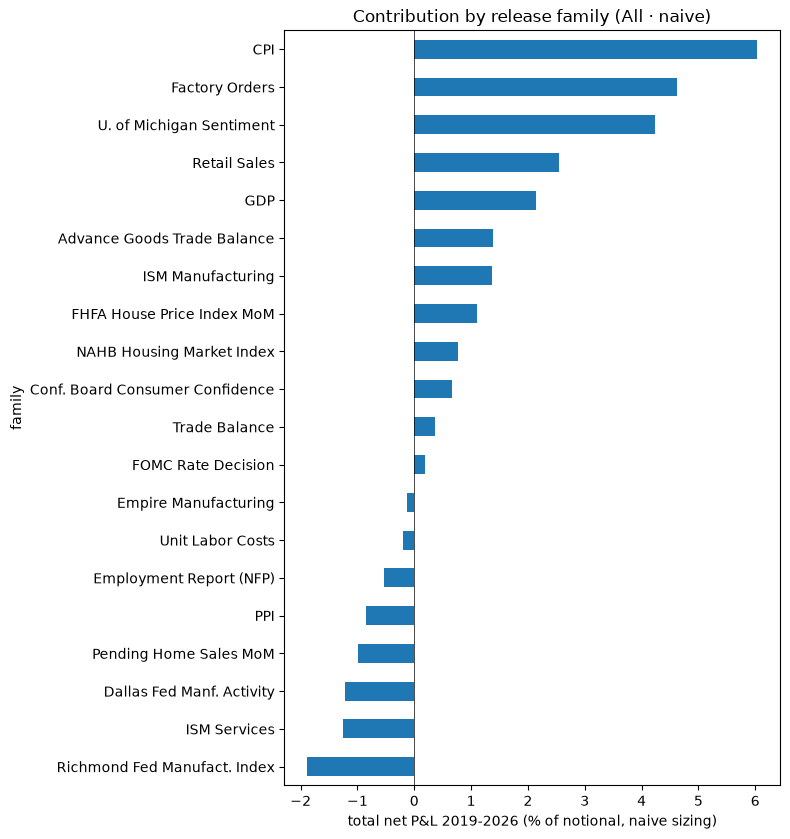

In [12]:
fam_naive = su.per_family_stats(P["All · naive"], PRIMARY_TARGET).add_prefix("naive_")
fam_vol = su.per_family_stats(P["All · signal × vol"], PRIMARY_TARGET).add_prefix("vol_")
fam_tab = fam_naive.join(fam_vol, how="outer").sort_values("naive_total_net_pct", ascending=False)
fam_tab.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_per_family.csv")
display(fam_tab.round(3))

ax = fam_tab["naive_total_net_pct"].sort_values().plot.barh(figsize=(8, 0.35 * len(fam_tab) + 1.5), color="C0")
ax.axvline(0, c="k", lw=0.5); ax.set_xlabel("total net P&L 2019-2026 (% of notional, naive sizing)")
ax.set_title("Contribution by release family (All · naive)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb05b_{MARKET}_family_contribution.png", dpi=150); plt.show()

### 9.3 Cumulative P&L

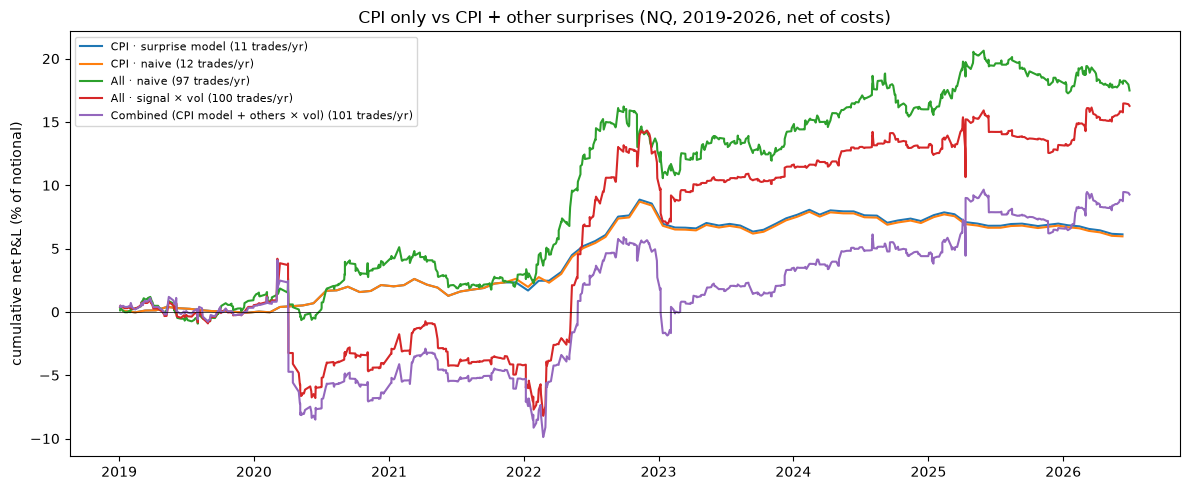

In [13]:
SHOW = ["CPI · surprise model", "CPI · naive", "All · naive", "All · signal × vol", "Combined (CPI model + others × vol)"]
fig, ax = plt.subplots(figsize=(12, 5))
for i, s in enumerate(SHOW):
    cum, _ = wf.drawdown_series(T[s], EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values, label=f"{s} ({perf.loc[s, 'trades_per_year']:.0f} trades/yr)", lw=1.5)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("cumulative net P&L (% of notional)")
ax.set_title(f"CPI only vs CPI + other surprises ({MARKET}, 2019-2026, net of costs)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb05b_{MARKET}_cumulative_pnl.png", dpi=150); plt.show()

### 9.4 Robustness: sub-periods, 2022, and the random-sign null

In [14]:
def sharpe_months(tr, start, end, drop_year=None):
    m = wf.monthly_returns(tr, start, end)
    if drop_year:
        m = m[m.index.year != drop_year]
    sd = m.std(ddof=1)
    return m.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

rob = []
for s in STRATS:
    obs, p_null = su.random_sign_pvalue(T[s], wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    (lo, _, hi), _ = wf.bootstrap_sharpe(T[s], EVAL_START, EVAL_END, N_BOOT)
    rob.append(dict(strategy=s, sharpe=obs, ci_5=lo, ci_95=hi,
                    sharpe_2019_21=sharpe_months(T[s], "2019-01-01", "2021-12-31"),
                    sharpe_2022_26=sharpe_months(T[s], "2022-01-01", EVAL_END),
                    sharpe_ex_2022=sharpe_months(T[s], EVAL_START, EVAL_END, drop_year=2022),
                    p_random_sign=p_null))
rob = pd.DataFrame(rob).set_index("strategy")
rob.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_robustness.csv")
display(rob.round(3))

,sharpe,ci_5,ci_95,sharpe_2019_21,sharpe_2022_26,sharpe_ex_2022,p_random_sign
strategy,,,,,,,
CPI · naive,0.535,-0.118,1.246,0.866,0.428,0.024,0.046
CPI · surprise model,0.554,-0.116,1.283,0.777,0.488,-0.014,0.047
CPI · signal × vol,0.745,0.087,1.383,0.905,0.711,0.170,0.013
All · naive,0.712,0.021,1.440,0.352,0.905,0.439,0.005
All · surprise model,0.372,-0.288,1.090,0.332,0.394,0.266,0.075
All · signal × vol,0.375,-0.251,1.082,-0.236,0.808,0.050,0.096
Combined (CPI model + others × vol),0.229,-0.377,0.973,-0.307,0.635,0.039,0.194
All · naive · 2nd window,-0.227,-0.894,0.393,-1.007,0.263,-0.479,0.531
All · signal × vol · 2 windows,-0.004,-0.672,0.794,-0.947,0.712,-0.420,0.327


**How to read it.**
- **`p_random_sign`** is the share of random-direction books, with the same trades, sizes and costs, whose Sharpe beats the strategy. Below 0.05 means the *direction* genuinely adds value.
- **`sharpe_ex_2022`** shows how much depends on the 2022 inflation shock.

### 9.5 Transaction costs

In [15]:
cost_rows = []
for ticks in [0, 1, 2, 4]:
    pt = panel.copy()
    pt["cost_bps"] = su.cost_bps(pt["pre_close"], ticks, COMMISSION_RT, TICK, MULT)
    for s, (fams, model) in {"CPI · surprise model": ("cpi", "surprise"), "All · naive": ("all", "naive"),
                             "All · signal × vol": ("all", "signal_vol")}.items():
        sub = pt[pt["family"] == CPI] if fams == "cpi" else pt[pt["admitted"]]
        tr = su.to_trades(su.build_positions(sub, hist, model, PRIMARY_TARGET, MIN_TRAIN, THRESHOLD), PRIMARY_TARGET, s)
        pf = wf.performance(tr, EVAL_START, EVAL_END, s)
        cost_rows.append(dict(ticks_rt=ticks, strategy=s, sharpe_net=pf["sharpe_net"], avg_net_bps=pf["avg_net_bps"], trades=pf["trades"]))
cost_tab = pd.DataFrame(cost_rows)
cost_tab.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_cost_sensitivity.csv", index=False)
display(cost_tab.pivot(index="ticks_rt", columns="strategy", values="sharpe_net").round(2))

strategy,All · naive,All · signal × vol,CPI · surprise model
ticks_rt,,,
0,0.820,0.430,0.610
1,0.770,0.400,0.590
2,0.710,0.370,0.550
4,0.600,0.320,0.540


### 9.6 Peer-format metrics (daily, one contract)

In [16]:
daily_close = sc.build_daily_close(es_adj)
days = daily_close.index[(daily_close.index >= pd.Timestamp(EVAL_START)) & (daily_close.index <= pd.Timestamp(EVAL_END))]
bh = wf.buy_hold_daily(daily_close, days)
peer = {s: wf.peer_metrics(wf.daily_returns(T[s], days), bh, trades_per_year=perf.loc[s, "trades_per_year"],
                           minutes_in_market=perf.loc[s, "trades"] * 30 / (len(days) * 23 * 60) * 100) for s in STRATS}
peer = pd.DataFrame(peer).T
peer.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_peer_metrics.csv")
display(peer.round(3))

,total_pct,vol_pct,sharpe,max_dd_pct,beta,corr,trades_per_year,time_in_market_pct
CPI · naive,5.967,1.517,0.540,-2.743,-0.002,-0.023,11.744,0.104
CPI · surprise model,6.123,1.505,0.559,-2.743,-0.002,-0.027,11.477,0.102
CPI · signal × vol,14.421,2.665,0.744,-4.274,-0.004,-0.032,11.744,0.104
All · naive,17.484,3.345,0.718,-5.662,0.001,0.005,96.751,0.859
All · surprise model,6.852,2.727,0.345,-4.827,0.003,0.024,66.191,0.588
All · signal × vol,16.265,5.047,0.443,-12.406,0.005,0.022,99.553,0.884
Combined (CPI model + others × vol),9.265,4.618,0.276,-13.971,0.006,0.031,100.887,0.896
All · naive · 2nd window,-4.628,2.690,-0.236,-10.488,-0.005,-0.042,96.751,0.859
All · signal × vol · 2 windows,-0.230,7.168,-0.004,-33.832,-0.002,-0.007,199.106,1.769


## 10. Final Comparison: CPI Only vs CPI + Other Surprises

In [17]:
FINAL = ["CPI · naive", "CPI · surprise model", "CPI · signal × vol",
         "All · naive", "All · surprise model", "All · signal × vol",
         "Combined (CPI model + others × vol)", "All · signal × vol · 2 windows"]
final = pd.DataFrame({
    "trades / yr": perf.loc[FINAL, "trades_per_year"],
    "days / yr": perf.loc[FINAL, "days_per_year"],
    "hit rate": perf.loc[FINAL, "hit_rate"],
    "net bps / trade": perf.loc[FINAL, "avg_net_bps"],
    "total net P&L %": perf.loc[FINAL, "total_net_pct"],
    "ann. return %": perf.loc[FINAL, "ann_return_pct"],
    "ann. vol %": perf.loc[FINAL, "ann_vol_pct"],
    "Sharpe (net)": perf.loc[FINAL, "sharpe_net"],
    "Sharpe ex-2022": rob.loc[FINAL, "sharpe_ex_2022"],
    "max DD %": perf.loc[FINAL, "max_dd_pct"],
    "beta": peer.loc[FINAL, "beta"],
    "P(random sign ≥)": rob.loc[FINAL, "p_random_sign"],
})
jack = pd.DataFrame({"trades / yr": 185, "days / yr": np.nan, "hit rate": np.nan, "net bps / trade": 1.18,
                     "total net P&L %": 18.597, "ann. return %": np.nan, "ann. vol %": 3.020, "Sharpe (net)": 0.613,
                     "Sharpe ex-2022": np.nan, "max DD %": -4.928, "beta": -0.005, "P(random sign ≥)": np.nan},
                    index=["Peer: Jack DTW (slide, 2018-2026)"])
final = pd.concat([final, jack])
final.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_final_comparison.csv")
display(final.round(3))

,trades / yr,days / yr,hit rate,net bps / trade,total net P&L %,ann. return %,ann. vol %,Sharpe (net),Sharpe ex-2022,max DD %,beta,P(random sign ≥)
CPI · naive,11.744,11.877,0.534,6.780,5.967,0.796,1.486,0.535,0.024,-2.743,-0.002,0.046
CPI · surprise model,11.477,11.477,0.535,7.120,6.123,0.816,1.472,0.554,-0.014,-2.743,-0.002,0.047
CPI · signal × vol,11.744,11.744,0.534,16.387,14.421,1.923,2.582,0.745,0.170,-4.274,-0.004,0.013
All · naive,96.751,89.544,0.530,2.412,17.484,2.331,3.276,0.712,0.439,-5.662,0.001,0.005
All · surprise model,66.191,63.388,0.534,1.381,6.852,0.914,2.455,0.372,0.266,-4.827,0.003,0.075
All · signal × vol,99.553,89.544,0.529,2.180,16.265,2.169,5.789,0.375,0.050,-12.406,0.005,0.096
Combined (CPI model + others × vol),100.887,90.879,0.528,1.226,9.265,1.235,5.402,0.229,0.039,-13.971,0.006,0.194
All · signal × vol · 2 windows,199.106,89.544,0.498,-0.015,-0.230,-0.031,8.730,-0.004,-0.420,-35.947,-0.002,0.327
"Peer: Jack DTW (slide, 2018-2026)",185.000,NaN,NaN,1.180,18.597,NaN,3.020,0.613,NaN,-4.928,-0.005,NaN


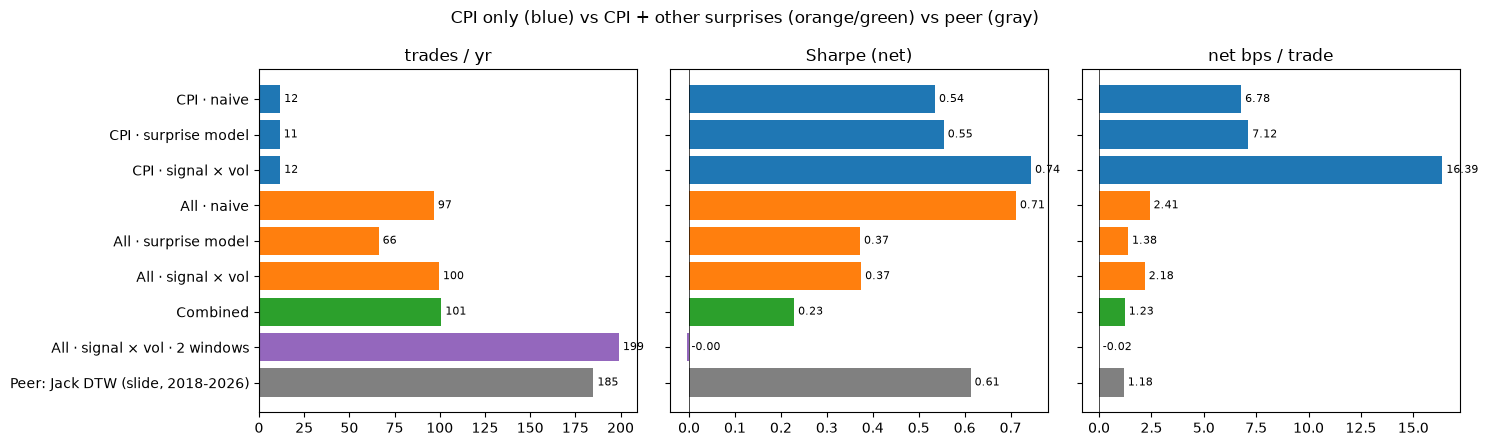

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
lab = [s.replace(" (CPI model + others × vol)", "") for s in final.index]
for ax, col in zip(axes, ["trades / yr", "Sharpe (net)", "net bps / trade"]):
    vals = final[col].values
    ax.barh(lab, vals, color=["C0"] * 3 + ["C1"] * 3 + ["C2", "C4", "gray"])
    ax.axvline(0, c="k", lw=0.5); ax.set_title(col); ax.invert_yaxis()
    for i, v in enumerate(vals):
        if np.isfinite(v):
            ax.text(v, i, f" {v:.2f}" if col != "trades / yr" else f" {v:.0f}", va="center", fontsize=8)
    if ax is not axes[0]:
        ax.set_yticklabels([])
plt.suptitle("CPI only (blue) vs CPI + other surprises (orange/green) vs peer (gray)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb05b_{MARKET}_final_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

### 10.1 Automatic summary

In [19]:
def line(s):
    r = final.loc[s]
    return (f"{s:<40s} {r['trades / yr']:6.0f} trades/yr | Sharpe {r['Sharpe (net)']:5.2f} | "
            f"{r['net bps / trade']:6.2f} bps/trade | total {r['total net P&L %']:6.2f}% | "
            f"maxDD {r['max DD %']:6.2f}% | ex-2022 Sharpe {r['Sharpe ex-2022']:5.2f} | P(random) {r['P(random sign ≥)']:.3f}")
print("=" * 120)
print(f"NOTEBOOK 05 SUMMARY — {MARKET}, 2019-2026, net of costs")
print("=" * 120)
print("CPI only:")
for s in FINAL[:3]: print("  " + line(s))
print("CPI + other surprises:")
for s in FINAL[3:]: print("  " + line(s))
print(f"\nPeer (Jack DTW slide): 185 trades/yr | Sharpe 0.61 | 1.18 bps/trade | total 18.6% | maxDD -4.9%")
best = final.drop(index=final.index[-1])["Sharpe (net)"].idxmax()
print(f"\nHighest net Sharpe: {best}")
print(f"Families admitted at least once: {', '.join(sorted(admitted_any.index))}")

NOTEBOOK 05 SUMMARY — NQ, 2019-2026, net of costs
CPI only:
  CPI · naive                                  12 trades/yr | Sharpe  0.54 |   6.78 bps/trade | total   5.97% | maxDD  -2.74% | ex-2022 Sharpe  0.02 | P(random) 0.046
  CPI · surprise model                         11 trades/yr | Sharpe  0.55 |   7.12 bps/trade | total   6.12% | maxDD  -2.74% | ex-2022 Sharpe -0.01 | P(random) 0.047
  CPI · signal × vol                           12 trades/yr | Sharpe  0.74 |  16.39 bps/trade | total  14.42% | maxDD  -4.27% | ex-2022 Sharpe  0.17 | P(random) 0.013
CPI + other surprises:
  All · naive                                  97 trades/yr | Sharpe  0.71 |   2.41 bps/trade | total  17.48% | maxDD  -5.66% | ex-2022 Sharpe  0.44 | P(random) 0.005
  All · surprise model                         66 trades/yr | Sharpe  0.37 |   1.38 bps/trade | total   6.85% | maxDD  -4.83% | ex-2022 Sharpe  0.27 | P(random) 0.075
  All · signal × vol                          100 trades/yr | Sharpe  0.37 |   2.1

## 11. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Trade count.** How many trades a year does CPI + other surprises give, compared with CPI only (about 7–11) and the peer strategy (185)?

**2. Edge per trade.** Does net bps per trade stay above the cost when weaker releases are added? Which families earn money (Section 9.2), and which only add costs?

**3. Risk-adjusted return.** Compare the Sharpe of CPI only, All, and Combined. Is the difference robust? Check `P(random sign ≥)`, the Sharpe excluding 2022, and the two sub-periods.

**4. Sizing.** Does Jack's signal × volatility sizing improve the multi-release book, as it did in his split test?

**5. Second window.** Does a second 30-minute trade after each release add profit, or only trades?

**6. Recommendation.** CPI only, CPI + others, or the combined book, and why.

# 12. Purpose, Research Questions, Answers, and Conclusion (NQ)

## Purpose of Notebook 05b (NQ)

Notebook 04b showed that trading NQ in the direction of the **CPI surprise** is profitable after costs (naive Sharpe 1.00), but with only about **8–11 trades a year**.

Notebook 05b repeats Notebook 05 on NQ and asks:

> **If we trade the surprises of many US macro releases on NQ, not only CPI, how many trades do we get, and do we keep a positive, credible edge after costs?**

**Design (identical to Notebook 05):** entry at the close of the first post-release bar (T+1), exit 30 minutes after the release, walk-forward over **2019–2026** with 2016–2018 as history. The impact screen and the line signs are estimated **on NQ's own reactions**. Costs are 2 ticks + $4.50 per round trip on the NQ contract, about **0.8 bps** on average (ES: about 1.7).

**Credits:** the release-family rule, the impact screen and the volatility-proportional sizing come from **Jack Duncan**; the ±5σ winsorisation from **Aaryen Mehta**; the causal surprises, executable entry and walk-forward engine from Notebooks 01–04.

---

## Research Questions and Answers

### Sections 2–3: Releases and surprises
**Answer:** Identical to ES, since they come from the same Bloomberg workbook: 27,137 release rows, 179 lines, **75 release families**, and 17,328 causal surprises, of which only 0.47% hit the ±5σ cap.

### Section 5: Does Notebook 05b reproduce Notebook 04b?
**Question:** Are the trade returns identical to Notebook 04b for the same CPI releases?

**Answer:** **Yes.** On all 79 CPI releases the 30-minute trade return matches Notebook 04b (maximum difference 1.4×10⁻¹⁴ bps).

### Section 6: Which releases does NQ react to?
**Question:** Which families move NQ more than other releases at the same clock time, using history only?

**Answer:** The top of the screen is very similar to ES. **CPI** ranks 1st every year from 2022, and the **Employment Report** 1st–4th. **ISM Services**, **ISM Manufacturing** and **Retail Sales** are regularly admitted, and **U. of Michigan** enters the top 10 from 2023. As in ES, the **FOMC decision** and the **interest on reserves** rate rank high from 2021–2023 but have almost no surprise to trade (1 FOMC trade in 7.5 years).

### Section 7: Is the direction signal sensible?
**Question:** With each line signed by its historical jump reaction on NQ, does the signal relate to NQ's reaction out of sample?

**Answer:** Yes, for most families. The correlation between the signal and the instant jump in 2019–2026 is **+0.56 for CPI**, +0.53 for U. of Michigan, +0.51 for Pending Home Sales, +0.44 for ISM Manufacturing and +0.41 for PPI. All CPI lines are correctly signed: a hot print pushes NQ down. A few small families are wrongly signed out of sample (FOMC −0.62, Unit Labor Costs −0.63).

### Section 9.1: How many trades, and how profitable?

| Strategy | Trades / yr | Days / yr | Net bps / trade | Total net P&L | Net Sharpe | Max DD |
|---|---|---|---|---|---|---|
| CPI · naive | 12 | 12 | 6.8 | 6.0% | 0.54 | −2.7% |
| CPI · surprise model | 11 | 11 | 7.1 | 6.1% | 0.55 | −2.7% |
| **CPI · signal × vol** | 12 | 12 | **16.4** | 14.4% | **0.74** | −4.3% |
| **All · naive** | **97** | **90** | 2.4 | **17.5%** | **0.71** | −5.7% |
| All · surprise model | 66 | 63 | 1.4 | 6.9% | 0.37 | −4.8% |
| All · signal × vol | 100 | 90 | 2.2 | 16.3% | 0.37 | −12.4% |
| Combined (CPI model + others × vol) | 101 | 91 | 1.2 | 9.3% | 0.23 | −14.0% |
| All · signal × vol · 2 windows | 199 | 90 | 0.0 | −0.2% | 0.00 | −35.9% |
| *Peer: Jack DTW (slide, ES)* | *185* | — | *1.2* | *18.6%* | *0.61* | *−4.9%* |

### Section 9.2: Which releases earn money?
**Answer:** Positive total net P&L (naive sizing): **CPI +6.0%**, Factory Orders +4.6%, U. of Michigan +4.2%, Retail Sales +2.6%, GDP +2.1%, Advance Goods Trade +1.4%, ISM Manufacturing +1.4%. Negative: Richmond Fed −1.9%, ISM Services −1.3%, Dallas Fed −1.2%, Pending Home Sales −1.0%, PPI −0.9%, Employment Report −0.5%. As in ES, **no major family is individually significant** (CPI with volatility sizing: t = 1.9). The broad book works through **diversification across many small edges**.

### Section 9.4: Is the edge robust?

| Strategy | Sharpe 2019–21 | Sharpe 2022–26 | Sharpe ex-2022 | Random-sign p |
|---|---|---|---|---|
| CPI · surprise model | 0.78 | 0.49 | −0.01 | 0.047 |
| CPI · signal × vol | 0.91 | 0.71 | 0.17 | 0.013 |
| **All · naive** | 0.35 | 0.91 | **0.44** | **0.005** |
| All · signal × vol | −0.24 | 0.81 | 0.05 | 0.096 |
| All · naive · 2nd window only | −1.01 | 0.26 | −0.48 | 0.53 |

- **The direction is real.** Only 5 of 1,000 random-direction books matched the multi-release naive book (p = 0.005).
- **The multi-release book depends much less on 2022** than CPI alone: its Sharpe excluding 2022 is **0.44** (ES: 0.28), against about 0 for CPI.
- **The second window loses money** (Sharpe −0.23, hit rate 47%). As in ES, the surprise's effect is gone within 30 minutes.

### Section 9.5: How sensitive is it to costs?

| Round-trip slippage | 0 ticks | 1 | 2 (base) | 4 |
|---|---|---|---|---|
| All · naive | 0.82 | 0.77 | 0.71 | **0.60** |
| CPI · surprise model | 0.61 | 0.59 | 0.55 | **0.54** |

Because NQ costs are low in basis points (a larger contract value per tick), the multi-release book is **far more cost-robust than in ES**: at 4 ticks it keeps a Sharpe of 0.60 (ES: 0.20).

### Section 9.6: Is it market-neutral?
**Answer:** Yes. Beta to buy-and-hold NQ is between −0.004 and +0.006 for every strategy, and time in market is below 1% (1.8% for the two-window book).

---

## The CPI Surprise Definition (as in ES)

The NQ **CPI naive** book in Notebook 05b (Sharpe 0.54) is again much weaker than in Notebook 04b (Sharpe 1.00), **with identical trade returns**. The reason is the same as in ES: Notebook 04 uses the headline CPI MoM surprise, while Notebook 05 averages all 8 CPI lines, and the two disagree in direction on releases where the headline surprise is close to zero. The surprise-model and signal × volatility versions, which trade little on small surprises, are more stable.

---

## Final Comparison: CPI Only vs CPI + Other Surprises (NQ)

| | **CPI only** (best: signal × vol) | **CPI + other surprises** (All · naive) | Peer: Jack DTW (ES) |
|---|---|---|---|
| Trades per year | 12 | **97** | 185 |
| Trading days per year | 12 | **90** | — |
| Net bps per trade | **16.4** | 2.4 | 1.2 |
| Total net P&L (2019–26) | 14.4% | **17.5%** | 18.6% (2018–26) |
| Net Sharpe | **0.74** | **0.71** | 0.61 |
| Max drawdown | −4.3% | −5.7% | −4.9% |
| Sharpe ex-2022 | 0.17 | **0.44** | — |
| Sharpe at 4-tick costs | — | **0.60** | — |

---

## Conclusion

**1. NQ supports a broad macro-surprise book.** Trading the surprises of about 10 screened releases gives **~97 trades a year on ~90 days**, against about 11 for CPI only.

**2. The edge is at least as good as in ES.** The multi-release book earns a **net Sharpe of 0.71** (ES: 0.65) with a −5.7% drawdown and 17.5% total P&L, above the peer DTW strategy's Sharpe (0.61). The direction is significant against random signs (p = 0.005).

**3. It is the most robust book in the project.** It depends less on 2022 (Sharpe ex-2022 0.44) and much less on execution costs (0.60 at 4 ticks) than the ES book.

**4. CPI remains the strongest single release.** With volatility sizing, CPI reaches **Sharpe 0.74** at **16 bps per trade**, but most of that comes from 2022.

**5. The effect lasts about 30 minutes.** As in ES, a second trade after each release loses money, and the two-window book has a Sharpe of 0.00. The honest ceiling is about **100 trades a year per market**.

**6. Sizing:** the simplest rule works best. Volatility sizing and per-family surprise models both **lower** the Sharpe of the broad book (0.37).

**Recommendation:** NQ is a **second equity market for the same strategy**. Its multi-release naive book is the strongest single result of the project. Combining it with the ES book is tested in Notebook 07.

**Caveats:** as in ES, the CPI result depends on the surprise definition for near-zero surprises; the screen admits families with no real surprise (FOMC, interest on reserves); and first-minute execution may cost more than 2 ticks.

> **Overall:** on NQ, trading the macro surprise across about 10 major US releases gives ~97 trades a year with a net Sharpe of 0.71, more robust to 2022 and to costs than the same book on ES.